In [1]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import cfg
from src.my_utils import *

from sklearn.model_selection import RepeatedStratifiedKFold

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from src.features import *
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


import torch.nn as nn
import torch

from skorch import NeuralNetBinaryClassifier
from skorch.callbacks import EarlyStopping, EpochScoring, LRScheduler
from skorch.dataset import ValidSplit
import random

from sklearn.model_selection import train_test_split
from skorch.dataset import Dataset
from skorch.helper import predefined_split
from sklearn.base import clone
from sklearn.metrics import accuracy_score

In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
gseed = cfg.general.seed
set_seed(gseed)


In [4]:
train_path = Path(cfg.paths.train)
submit_path = Path(cfg.paths.test)


In [5]:
df_train = pd.read_csv(train_path)
df_submit = pd.read_csv(submit_path)


In [6]:
X_train = df_train.drop(columns=["Survived"])
y_train = df_train["Survived"]


X_submit = df_submit.copy()


In [7]:
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=gseed)

In [8]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [17]:
class MLP2(nn.Module):
    def __init__(self, n_features, use_bn=False, use_do=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 8),
            nn.BatchNorm1d(8) if use_bn else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(0.5) if use_do else nn.Identity(),
            nn.Linear(8, 1),
        )

    def forward(self, X):
        return self.net(X)

### feature impoortance

In [13]:
preprocessor = Pipeline(
    [
        ("dtypes", DtypesTransformer()),
        ("title_transformer", TitleTransformer()),
        ("age_imputer", ByPclassAgeImputer()),
        ("embarked_imputer", EmbarkedImputer()),
        ("fare_imputer", FareImputer()),
        ("group_transformer", GroupTransformer(smooth=1e-6)),
        ("cabin_transformer", AdvancedCabinTransformer()),
        (
            "column_transformer",
            ColumnTransformer(
                [
                    (
                        "cat_ohe",
                        OneHotEncoder(sparse_output=False, drop="first"),
                        ["Pclass", "Sex", "Title", "Has_Cabin", "Deck", "Embarked"],
                    ),
                    (
                        "num",
                        StandardScaler(),
                        [
                            "Age",
                            "SibSp",
                            "Parch",
                            "Ticket_Group_Size",
                            "Fare",
                            "True_Fare",
                            "Log_True_Fare",
                            "Ticket_Survival_Rate",
                        ],
                    ),
                ],
                remainder="drop",
                verbose_feature_names_out=False,
            ).set_output(transform="pandas"),
        ),
        ("to_numpy", ToFloat32Transformer()),
    ]
)

In [14]:
n_features = preprocessor.fit_transform(X_train, y_train).shape[1]


def make_net():
    return NeuralNetBinaryClassifier(
        module=MLP2,
        module__n_features=n_features,
        max_epochs=2000,
        lr=3e-4,
        optimizer=torch.optim.Adam,
        batch_size=32,
        train_split=ValidSplit(cv=0.15, stratified=True, random_state=gseed),
        callbacks=[
            EpochScoring(scoring="accuracy", lower_is_better=False, name="valid_acc"),
            EarlyStopping(monitor="valid_loss", patience=15, load_best=True),
        ],
        iterator_train__shuffle=True,
        iterator_train__worker_init_fn=seed_worker,
    )


In [14]:
feature_names = preprocessor.fit_transform(X_train, y_train).columns

feature_groups = {
    "Pclass": [col for col in feature_names if col.startswith("Pclass")],
    "Sex": [col for col in feature_names if col.startswith("Sex")],
    "Title": [col for col in feature_names if col.startswith("Title")],
    "Has_Cabin": [col for col in feature_names if col.startswith("Has_Cabin")],
    "Deck": [col for col in feature_names if col.startswith("Deck")],
    "Embarked": [col for col in feature_names if col.startswith("Embarked")],
    "Age": ["Age"],
    "SibSp": ["SibSp"],
    "Parch": ["Parch"],
    "Ticket_Group_Size": ["Ticket_Group_Size"],
    "Fare": ["Fare"],
    "True_Fare": ["True_Fare"],
    "Log_True_Fare": ["Log_True_Fare"],
    "Ticket_Survival_Rate": ["Ticket_Survival_Rate"],
}

In [15]:
group_importance_folds = {name: [] for name in feature_groups}
base_scores = []
n_reps = 5


In [16]:
from tqdm.notebook import tqdm

total_splits = rskf.get_n_splits()
total_splits

50

In [17]:
for fold_idx, (train_idx, val_idx) in enumerate(
    tqdm(rskf.split(X_train, y_train), total=total_splits)
):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr = preprocessor.fit_transform(X_tr, y_tr)
    X_val = preprocessor.transform(X_val)

    X_tr_np = X_tr.to_numpy().astype("float32")
    y_tr_np = y_tr.to_numpy().astype("float32")
    X_val_np = X_val.to_numpy().astype("float32")
    y_val_np = y_val.to_numpy().astype("float32")

    set_seed(gseed)
    fold_net = make_net()
    fold_net.fit(X_tr_np, y_tr_np)

    base_preds = fold_net.predict(X_val_np)
    base_score = accuracy_score(y_val_np, base_preds)
    base_scores.append(base_score)

    for group_name, cols in feature_groups.items():
        existing_cols = [c for c in cols if c in X_val.columns]
        if not existing_cols:
            continue

        scores_drop = []
        for rep in range(n_reps):
            rng = np.random.RandomState(gseed * 1000 + fold_idx * 100 + rep)
            X_perm = X_val.copy()
            shuffled_indices = rng.permutation(X_perm.index)
            X_perm[existing_cols] = X_perm.loc[shuffled_indices, existing_cols].values

            X_perm_np = X_perm.to_numpy().astype("float32")
            perm_preds = fold_net.predict(X_perm_np)
            perm_score = accuracy_score(y_val_np, perm_preds)

            scores_drop.append(base_score - perm_score)

        group_importance_folds[group_name].append(np.mean(scores_drop))


  0%|          | 0/50 [00:00<?, ?it/s]

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7104       0.3719        0.7023  0.0264
      2        0.6971       0.5620        0.6914  0.0246
      3        0.6854       0.6446        0.6818  0.0234
      4        0.6749       0.6612        0.6733  0.0183
      5        0.6657       0.6694        0.6658  0.0215
      6        0.6574       0.6694        0.6593  0.0206
      7        0.6497       0.6612        0.6524  0.0177
      8        0.6418       0.6694        0.6458  0.0196
      9        0.6341       0.6694        0.6393  0.0207
     10        0.6269       0.6612        0.6331  0.0183
     11        0.6197       0.6612        0.6272  0.0190
     12        0.6130       0.6777        0.6213  0.0212
     13        0.6063       0.6777        0.6156  0.0207
     14        0.5997       0.6860        0.6100  0.0194
     15        0.5935       0.7025        0.6044  0.0187
     16        0.5873       0.7

In [20]:
importance_summary = pd.DataFrame(
    {
        name: {
            "Importance_Drop_Mean": np.mean(vals),
            "Importance_Drop_Std": np.std(vals),
        }
        for name, vals in group_importance_folds.items()
    }
).T.sort_values("Importance_Drop_Mean", ascending=False)

print(
    f"Базовая accuracy на val по фолдам: {np.mean(base_scores):.4f} +/- {np.std(base_scores):.4f}"
)
print("Рейтинг важности признаков (среднее падение Accuracy по фолдам, +/- std):")
print(importance_summary)


Базовая accuracy на val по фолдам: 0.8375 +/- 0.0344
Рейтинг важности признаков (среднее падение Accuracy по фолдам, +/- std):
                      Importance_Drop_Mean  Importance_Drop_Std
Title                             0.114853             0.038735
Sex                               0.032303             0.025740
Ticket_Survival_Rate              0.019619             0.020336
Age                               0.013282             0.019791
Log_True_Fare                     0.008261             0.018070
Pclass                            0.007308             0.012361
True_Fare                         0.005464             0.013242
Deck                              0.004302             0.014262
Parch                             0.004212             0.010289
SibSp                             0.003377             0.011318
Has_Cabin                         0.002916             0.012132
Fare                              0.001616             0.006813
Embarked                         -0.00031

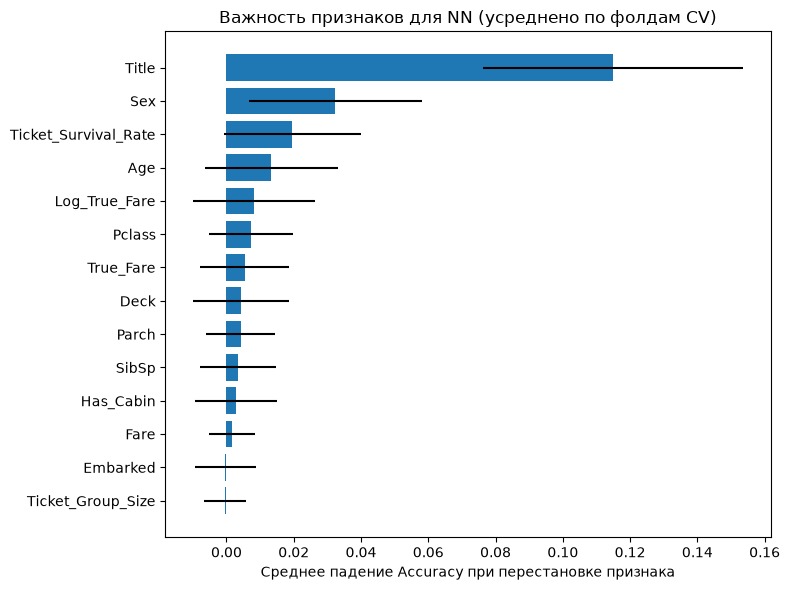

In [21]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_summary.index,
    importance_summary["Importance_Drop_Mean"],
    xerr=importance_summary["Importance_Drop_Std"],
)
plt.gca().invert_yaxis()
plt.xlabel("Среднее падение Accuracy при перестановке признака")
plt.title("Важность признаков для NN (усреднено по фолдам CV)")
plt.tight_layout()
plt.show()


Далее будут использовать фичи: Title, Sex, Ticket_Survival_Rate, Age, Log_True_Fare, Pclass, Deck, Parch, SibSp

### proxy epoch counter

In [11]:
callbacks = [
    (
        "cb_valid_acc",
        EpochScoring(
            scoring="accuracy", name="valid_acc", lower_is_better=False, on_train=False
        ),
    ),
    (
        "lr_scheduler",
        LRScheduler(
            policy=torch.optim.lr_scheduler.ReduceLROnPlateau,
            monitor="valid_acc",
            mode="max",
            patience=10,
            factor=0.5,
        ),
    ),
    (
        "early_stopping",
        EarlyStopping(
            monitor="valid_acc", patience=25, lower_is_better=False, load_best=True
        ),
    ),
]


In [12]:
nn_preproc = Pipeline(
    [
        ("dtypes", DtypesTransformer()),
        ("title_transformer", TitleTransformer()),
        ("age_imputer", ByPclassAgeImputer()),
        ("embarked_imputer", EmbarkedImputer()),
        ("fare_imputer", FareImputer()),
        ("group_transformer", GroupTransformer(smooth=1e-6)),
        ("cabin_transformer", AdvancedCabinTransformer()),
        (
            "column_transformer",
            ColumnTransformer(
                [
                    (
                        "cat_ohe",
                        OneHotEncoder(sparse_output=False, drop="first"),
                        ["Pclass", "Sex", "Title", "Deck"],
                    ),
                    (
                        "num",
                        StandardScaler(),
                        [
                            "Age",
                            "SibSp",
                            "Parch",
                            "Log_True_Fare",
                            "Ticket_Survival_Rate",
                        ],
                    ),
                ],
                remainder="drop",
                verbose_feature_names_out=False,
            ).set_output(transform="pandas"),
        ),
        ("to_numpy", ToFloat32Transformer()),
    ]
)

In [22]:
n_features = nn_preproc.fit_transform(X_train, y_train).shape[1]
proxy_net = NeuralNetBinaryClassifier(
    module=MLP2,
    module__n_features=n_features,
    max_epochs=2000,
    lr=3e-4,
    optimizer=torch.optim.Adam,
    batch_size=32,
    train_split=None,
    callbacks=callbacks,
    iterator_train__shuffle=True,
    iterator_train__worker_init_fn=seed_worker,
    verbose=0,
)

In [23]:
count_epochs(proxy_net, nn_preproc, X_train, y_train, n_repeats=9, base_seed=gseed)

51

In [24]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net, nn_preproc, X_train, y_train, rskf, best_epochs=51, base_seed=gseed
)
metrics

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.838559,0.007949,0.818649,0.040977,0.819304


# architecture

In [13]:
class MLP2(nn.Module):
    def __init__(self, n_features, use_bn=False, use_do=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 8),
            nn.BatchNorm1d(8) if use_bn else nn.Identity(),
            nn.ReLU(),
            nn.Dropout(0.3) if use_do else nn.Identity(),
            nn.Linear(8, 1),
        )

    def forward(self, X):
        return self.net(X)

In [44]:
n_features = nn_preproc.fit_transform(X_train, y_train).shape[1]
proxy_net = NeuralNetBinaryClassifier(
    module=MLP2,
    module__n_features=n_features,
    max_epochs=2000,
    lr=3e-4,
    optimizer=torch.optim.Adam,
    batch_size=32,
    train_split=None,
    callbacks=callbacks,
    iterator_train__shuffle=True,
    iterator_train__worker_init_fn=seed_worker,
    verbose=0,
)

In [45]:
best_epochs = count_epochs(
    proxy_net, nn_preproc, X_train, y_train, n_repeats=9, base_seed=gseed
)

In [46]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net,
    nn_preproc,
    X_train,
    y_train,
    rskf,
    best_epochs=best_epochs,
    base_seed=gseed,
)
metrics

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.838559,0.007949,0.818649,0.040977,0.819304


In [29]:
metrics_dict = metrics.iloc[0].to_dict()
log_experiment(
    model_name="nn",
    metrics=metrics_dict,
    note="small base mlp2",
)

### bn and dropout

In [ ]:
n_features = nn_preproc.fit_transform(X_train, y_train).shape[1]
proxy_net = NeuralNetBinaryClassifier(
    module=MLP2,
    module__n_features=n_features,
    module__use_bn=False,
    module__use_do=True,
    max_epochs=2000,
    lr=3e-4,
    optimizer=torch.optim.Adam,
    batch_size=32,
    train_split=None,
    callbacks=callbacks,
    iterator_train__shuffle=True,
    iterator_train__worker_init_fn=seed_worker,
    iterator_train__drop_last=True,
    verbose=0,
)


In [52]:
best_epochs = count_epochs(
    proxy_net, nn_preproc, X_train, y_train, n_repeats=9, base_seed=gseed
)

In [53]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net,
    nn_preproc,
    X_train,
    y_train,
    rskf,
    best_epochs=best_epochs,
    base_seed=gseed,
)
metrics

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.831925,0.009858,0.818422,0.034447,0.829405


In [54]:
metrics_dict = metrics.iloc[0].to_dict()
log_experiment(
    model_name="nn",
    metrics=metrics_dict,
    note="small base mlp2 + dropout",
)

### mlp3

In [14]:
class MLP3(nn.Module):
    def __init__(self, n_features, use_bn=False, use_do=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Linear(8, 1),
        )

    def forward(self, X):
        return self.net(X)

In [15]:
n_features = nn_preproc.fit_transform(X_train, y_train).shape[1]
proxy_net = NeuralNetBinaryClassifier(
    module=MLP3,
    module__n_features=n_features,
    module__use_bn=False,
    module__use_do=True,
    max_epochs=2000,
    lr=3e-4,
    optimizer=torch.optim.Adam,
    batch_size=32,
    train_split=None,
    callbacks=callbacks,
    iterator_train__shuffle=True,
    iterator_train__worker_init_fn=seed_worker,
    iterator_train__drop_last=True,
    verbose=0,
)


In [ ]:
best_epochs = count_epochs(
    proxy_net, nn_preproc, X_train, y_train, n_repeats=15, base_seed=gseed
)
best_epochs

24

In [ ]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net,
    nn_preproc,
    X_train,
    y_train,
    rskf,
    best_epochs=best_epochs + 15,
    base_seed=gseed,
)
metrics

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.864023,0.008514,0.840634,0.040783,0.84624


In [ ]:
metrics_dict = metrics.iloc[0].to_dict()
log_experiment(
    model_name="nn",
    metrics=metrics_dict,
    note="mlp3 + batch norm + some extra epochs",
)

In [ ]:
log_dir = Path(cfg.paths.logs)
log_file_path = log_dir / "experiments.log"

df_raw = pd.read_json(log_file_path, lines=True)

df_metrics = pd.json_normalize(df_raw["metrics"])

df = pd.concat([df_raw.drop(columns=["metrics"]), df_metrics], axis=1)

df[df["model"] == "nn"].sort_values(
    by=["OOF_acc", "VAL_acc_MEAN", "VAL_acc_STD"], ascending=[False, False, True]
)


,timestamp,model,note,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
15,2026-09-07 08:33:14,nn,mlp3 + batch norm + some extra epochs,0.864023,0.008514,0.840634,0.040783,0.846240
13,2026-09-07 08:09:48,nn,small base mlp2 + batch norm,0.850755,0.006519,0.835705,0.038154,0.836139
14,2026-09-07 08:20:31,nn,small base mlp2 + dropout,0.831925,0.009858,0.818422,0.034447,0.829405
12,2026-09-07 08:03:11,nn,small base mlp2,0.838559,0.007949,0.818649,0.040977,0.819304


Накинув сверху несколько дополнительных эпох скор становится лучше, тогда лучше переписать nn_cv_result

In [ ]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net,
    nn_preproc,
    X_train,
    y_train,
    rskf,
    base_seed=gseed,
)
metrics  # оптимальное число эпох не требуется, прежний синтаксис поддерживается, просто без эффекта

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.846791,0.019118,0.854994,0.038115,0.848485


Финальная модель

In [25]:
fitted_models, oof_preds, metrics = nn_cv_result(
    proxy_net,
    nn_preproc,
    X_train,
    y_train,
    rskf,
    base_seed=gseed,
)
metrics

,TRAIN_acc_MEAN,TRAIN_acc_STD,VAL_acc_MEAN,VAL_acc_STD,OOF_acc
0,0.847337,0.018191,0.854342,0.036345,0.855219


In [26]:
test_preds_list = []

for fold in fitted_models:
    preproc = fold["preprocessor"]
    model = fold["model"]

    X_test_np = preproc.transform(df_submit)
    preds = model.predict_proba(X_test_np)
    test_preds_list.append(preds)

final_probs = np.mean(test_preds_list, axis=0)
final_sub_preds = np.argmax(final_probs, axis=1)

final_sub_preds.shape

(418,)

In [27]:
submission = pd.DataFrame(
    {"PassengerId": df_submit["PassengerId"], "Survived": final_sub_preds}
)
submission.to_csv(Path(cfg.paths.output) / "nn_ans_submission.csv", index=False)